# Deployed app

Render URL: PASTE_RENDER_URL_HERE

Please open the deployed app first. Render Free may take around one minute to wake up after inactivity, so it can load while the notebook/code is being reviewed.


# K-Means - California Housing

En este proyecto voy a usar aprendizaje no supervisado para crear grupos de casas y después entrenar un modelo supervisado que aprenda a reproducir esos grupos.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('apple.mplstyle')
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="X does not have valid feature names")

SEPARATOR = "\n" + 120 * '-' + "\n"

## 1. Carga del dataset

In [2]:
df = pd.read_csv('../data/raw/housing.csv')

print(f"Shape: {df.shape}")
display(df.head())
print(SEPARATOR)

print("Info del dataset:\n")
df.info()
print(SEPARATOR)

print("Nulos por columna:\n")
display(df.isna().sum().to_frame("nulos"))
print(SEPARATOR)

print("Tipos de datos:\n")
display(df.dtypes.to_frame("dtype"))

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



------------------------------------------------------------------------------------------------------------------------

Info del dataset:

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

------------------------------------------------------------------------------------------------------------------------

Nulos por columna:



,nulos
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0



------------------------------------------------------------------------------------------------------------------------

Tipos de datos:



,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


## 2. Selección de variables

El enunciado pide trabajar con `Latitude`, `Longitude` y `MedInc`.

In [3]:
FEATURES = ["Latitude", "Longitude", "MedInc"]

X = df[FEATURES].copy()

print(f"X shape: {X.shape}")
display(X.head())
print(SEPARATOR)

print("Describe de X:")
display(X.describe().round(2))

X shape: (20640, 3)


,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462



------------------------------------------------------------------------------------------------------------------------

Describe de X:


,Latitude,Longitude,MedInc
count,20640.00,20640.00,20640.00
mean,35.63,-119.57,3.87
std,2.14,2.00,1.90
min,32.54,-124.35,0.50
25%,33.93,-121.80,2.56
50%,34.26,-118.49,3.53
75%,37.71,-118.01,4.74
max,41.95,-114.31,15.00


## 3. Split en train y test

Entrenamos el `clustering` con `train` y después usamos `test` como puntos nuevos.

In [4]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Tamaño de X_train: {X_train.shape[0]} registros.")
print(f"Tamaño de X_test:  {X_test.shape[0]} registros.")

Tamaño de X_train: 16512 registros.
Tamaño de X_test:  4128 registros.


## 4. Escalado

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test.index)

print("Describe de X_train_scaled:")
display(X_train_scaled.describe().round(2))

joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler guardado en ../models/scaler.pkl")

Describe de X_train_scaled:


,Latitude,Longitude,MedInc
count,16512.00,16512.00,16512.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.45,-2.38,-1.78
25%,-0.80,-1.11,-0.69
50%,-0.65,0.53,-0.18
75%,0.97,0.78,0.47
max,2.95,2.63,5.84


Scaler guardado en ../models/scaler.pkl


## 5. Modelo K-Means

El enunciado dice `6 clusters`. Después guardamos la etiqueta asignada a cada fila en una columna nueva llamada `cluster`.

In [6]:
km = KMeans(n_clusters=6, random_state=42, n_init=10)
km.fit(X_train_scaled)

train = X_train.copy()
train["cluster"] = km.predict(X_train_scaled).astype(int)

print("Conteo por cluster (train):")
display(train["cluster"].value_counts().sort_index().to_frame("n"))
print(SEPARATOR)
print(f"Inercia: {km.inertia_:.2f}")

Conteo por cluster (train):


,n
cluster,
0,1321
1,3380
2,453
3,3931
4,2239
5,5188



------------------------------------------------------------------------------------------------------------------------

Inercia: 8069.19


## 6. Visualización de clusters

Para visualizar en 2D usamos `Longitude` y `Latitude`. El color representa el cluster creado por `KMeans`.


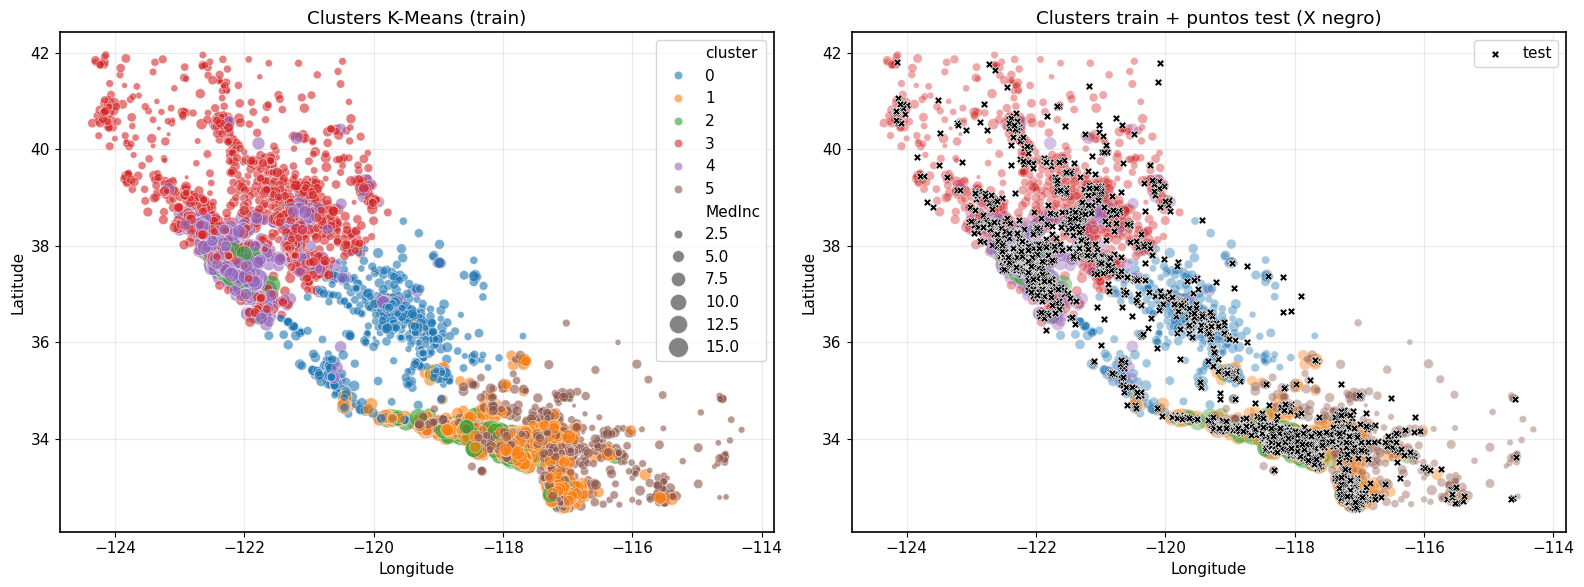


------------------------------------------------------------------------------------------------------------------------

MedInc promedio y mediana por cluster (train):


,n,MedInc_mean,MedInc_median
cluster,,,
0,1321,2.63,2.56
1,3380,5.31,5.10
2,453,10.44,10.12
3,3931,2.84,2.89
4,2239,5.52,5.22
5,5188,2.78,2.85


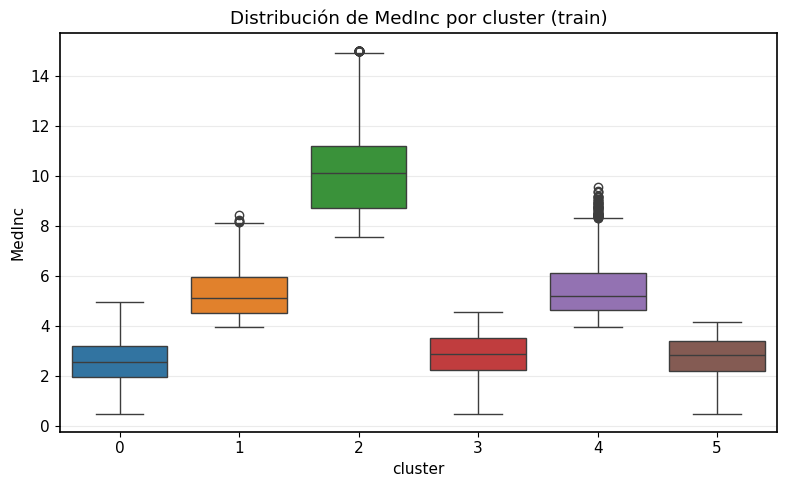

In [7]:
test = X_test.copy()
test["cluster"] = km.predict(X_test_scaled).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=train,
    x="Longitude", y="Latitude",
    hue="cluster", size="MedInc",
    sizes=(10, 200), palette="tab10",
    alpha=0.6, ax=axes[0],
)
axes[0].set_title("Clusters K-Means (train)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sns.scatterplot(
    data=train,
    x="Longitude", y="Latitude",
    hue="cluster", size="MedInc",
    sizes=(10, 200), palette="tab10",
    alpha=0.4, ax=axes[1], legend=False,
)
sns.scatterplot(
    data=test,
    x="Longitude", y="Latitude",
    color="black", marker="X", s=30,
    ax=axes[1], label="test",
)
axes[1].set_title("Clusters train + puntos test (X negro)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()
print(SEPARATOR)

print("MedInc promedio y mediana por cluster (train):")
display(
    train.groupby("cluster")["MedInc"]
    .agg(["count", "mean", "median"])
    .round(2)
    .rename(columns={"count": "n", "mean": "MedInc_mean", "median": "MedInc_median"})
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=train, x="cluster", y="MedInc", hue="cluster", palette="tab10", legend=False, ax=ax)
ax.set_title("Distribución de MedInc por cluster (train)")
plt.tight_layout()
plt.show()

#### Lectura del boxplot

- `Cluster 2` (verde, costa sur) es el menos denso en cantidad de puntos, pero tiene `MedInc` muy por encima del resto: mediana 10.12 frente a valores entre 2.6 y 2.9 y 5.3 y 5.5 en los otros clusters.
- `Clusters 0, 3 y 5` cubren la mayor superficie del estado, pero concentran los `MedInc` más bajos.
- `Clusters 1 y 4` son la zona media, con `MedInc` en torno a 5.


## 7. Modelo supervisado

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_scaled, train["cluster"])

train_pred = rf.predict(X_train_scaled)
print(f"Accuracy en train: {accuracy_score(train['cluster'], train_pred):.4f}")

Accuracy en train: 1.0000


`Accuracy` en `train` = 1.0 es normal. `RandomForest` con 200 árboles sin ajustar, memoriza todos los datos de `train`. La métrica que importa es `accuracy` en `test`, que la vamos a calcular ahora.

Accuracy en test: 0.9956

------------------------------------------------------------------------------------------------------------------------

Classification report (test):
              precision    recall  f1-score   support

           0     0.9970    0.9852    0.9910       337
           1     0.9952    0.9976    0.9964       829
           2     1.0000    0.9821    0.9910       112
           3     0.9948    0.9938    0.9943       962
           4     0.9884    0.9961    0.9922       514
           5     0.9985    0.9993    0.9989      1374

    accuracy                         0.9956      4128
   macro avg     0.9957    0.9923    0.9940      4128
weighted avg     0.9956    0.9956    0.9956      4128


------------------------------------------------------------------------------------------------------------------------

F1 macro en test: 0.9940

------------------------------------------------------------------------------------------------------------------------



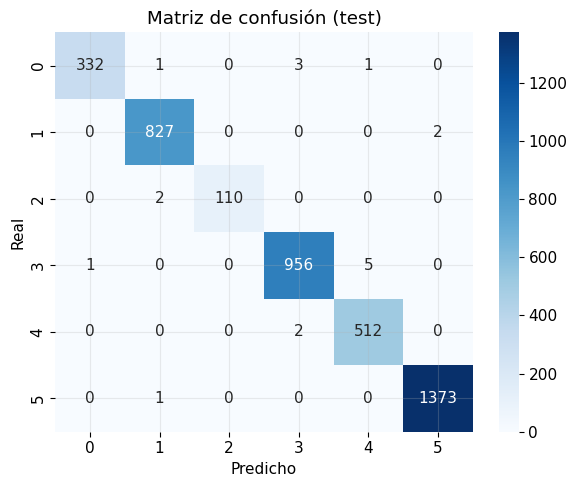

In [9]:
y_test = km.predict(X_test_scaled).astype(int)
test_pred = rf.predict(X_test_scaled)

print(f"Accuracy en test: {accuracy_score(y_test, test_pred):.4f}")
print(SEPARATOR)
print("Classification report (test):")
print(classification_report(y_test, test_pred, digits=4))
print(SEPARATOR)

print(f"F1 macro en test: {f1_score(y_test, test_pred, average='macro'):.4f}")
print(SEPARATOR)

cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[str(i) for i in range(6)],
    yticklabels=[str(i) for i in range(6)],
    ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión (test)")
plt.tight_layout()
plt.show()

## 8. Guardado de modelos

In [10]:
joblib.dump(km, '../models/kmeans.pkl')
joblib.dump(rf, '../models/supervised.pkl')

print("Modelos guardados en ../models/:")
print("- kmeans.pkl")
print("- scaler.pkl --> (guardado anteriormente en la celda del scaler)")
print("- supervised.pkl")

Modelos guardados en ../models/:
- kmeans.pkl
- scaler.pkl --> (guardado anteriormente en la celda del scaler)
- supervised.pkl


## 9. Predicción simulada de 3 casas en la zona

Para validar que el `KMeans` y el `modelo supervisado` separan zonas geográficamente coherentes, voy a probar `predict_cluster` con 3 ciudades reales:

- San Francisco (costa norte, ingreso alto).
- Los Ángeles (costa sur, ingreso medio).
- Fresno (interior del estado, ingreso bajo).

In [11]:
def predict_cluster(lat, lon, medinc):
    sample = pd.DataFrame(
        [[lat, lon, medinc]],
        columns=FEATURES,
        index=["pred"],
    )
    sample = sample[scaler.feature_names_in_]
    sample_scaled = scaler.transform(sample)
    return int(km.predict(sample_scaled)[0])


print("Ejemplos de predicción:")
print(f" - San Francisco  (37.77, -122.42, MedInc 8.5):  cluster {predict_cluster(37.77, -122.42, 8.5)}")
print(f" - Los Ángeles    (34.05, -118.25, MedInc 4.2):  cluster {predict_cluster(34.05, -118.25, 4.2)}")
print(f" - Fresno         (36.74, -119.78, MedInc 2.8):  cluster {predict_cluster(36.74, -119.78, 2.8)}")

Ejemplos de predicción:
 - San Francisco  (37.77, -122.42, MedInc 8.5):  cluster 4
 - Los Ángeles    (34.05, -118.25, MedInc 4.2):  cluster 1
 - Fresno         (36.74, -119.78, MedInc 2.8):  cluster 0


## 10. Conclusiones

- El `modelo KMeans` con `6 clusters` agrupa California en 6 zonas geográficamente coherentes.
- El `MedInc` se distribuye de forma desigual. El `cluster 2` (zona costera del sur) tiene la `mediana` de ingreso más alta con 10.12, mientras que los `clusters 0, 3 y 5` (costa central e interior) se quedan entre 2.6 y 2.9.
- El `modelo supervisado RandomForest` reproduce casi a la perfección las etiquetas del `KMeans`, con un `accuracy` en `test` de 0.9956 y un `f1_score` macro de 0.994. El `cluster 2` es el que más le cuesta (`recall` 0.9821).
- Los puntos de `test` se distribuyen bien sobre las mismas zonas que el `train`, así que el `KMeans` separa por geografía de forma estable.
- Los `clusters` son una construcción del algoritmo, no una categoría real como si fueran barrios o distritos reales. El modelo supervisado aprende a predecirlos, no a encontrar una verdad objetiva.
